# Downscaling with UNET Tutorial
* Author: James Redman
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-13
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.

## Introduction

In this tutorial we train a UNET - a convolutional neural network originally developed for medical image segmentation - to downscale daily climate fields over South Africa. We use output from a regional climate model (RCM) as our high-resolution target, and large-scale atmospheric fields from upscaled RCM data as our predictors. This is referred to as perfect model training.

By the end of this notebook you will have:
- Loaded and preprocessed climate data for training, validation and testing
- Trained a UNET to downscale either precipitaion (pr) or near surface maximum tempearture (tasmax)
- Run inference to evalute the model against RCM truth usign a range of diagnostic plots

In [1]:
from copy import deepcopy

import torch
import torch.nn as nn
from torch.optim.lr_scheduler import OneCycleLR
import numpy as np

import json

import torch
import numpy as np
import xarray as xr
import einops
import pandas as pd

import pathlib
import sys
import os
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime

from math import log2


import torch.nn.functional as F
from scipy.stats import gamma

import mlflow

from matplotlib.patches import Rectangle

## 1. Data

We use output from the CORDEXBecnh dataset over South Africa. The predictors are large-scale atmospheric fields (zonal wind, meridional wind, specific humidity, tempearture and geopotential height) at three pressure levels (500, 700 and 850 hPa). The target is either daily precipitation rate (pr) or near surface maximum temperaure (tasmax).

Note that the static predictor orography has not been included as a predictor in this notebook. This is a natural model extension to explore.

We first load the full predictor and target datasets.

In [2]:
# Training data paths
predictors_data_path = '/gws/ssde/j25a/mmh_storage/ai4c_data/cordexbench/SA_domain/train/Emulator_hist_future/predictors/ACCESS-CM2_1961-1980_2080-2099.nc'
targets_data_path = '/gws/ssde/j25a/mmh_storage/ai4c_data/cordexbench/SA_domain/train/Emulator_hist_future/target/pr_tasmax_ACCESS-CM2_1961-1980_2080-2099.nc'

ds_pred = xr.open_dataset(predictors_data_path)
ds_tgt = xr.open_dataset(targets_data_path)

print(ds_pred)
print(ds_tgt)

<xarray.Dataset> Size: 225MB
Dimensions:    (time: 14600, bnds: 2, lat: 16, lon: 16)
Coordinates:
  * time       (time) datetime64[ns] 117kB 1961-01-01T12:00:00 ... 2099-12-31...
  * lat        (lat) float64 128B -40.0 -38.0 -36.0 -34.0 ... -14.0 -12.0 -10.0
  * lon        (lon) float64 128B 11.0 13.0 15.0 17.0 ... 35.0 37.0 39.0 41.0
Dimensions without coordinates: bnds
Data variables: (12/16)
    time_bnds  (time, bnds) datetime64[ns] 234kB ...
    t_500      (time, lat, lon) float32 15MB ...
    t_700      (time, lat, lon) float32 15MB ...
    t_850      (time, lat, lon) float32 15MB ...
    u_500      (time, lat, lon) float32 15MB ...
    u_700      (time, lat, lon) float32 15MB ...
    ...         ...
    z_500      (time, lat, lon) float32 15MB ...
    z_700      (time, lat, lon) float32 15MB ...
    z_850      (time, lat, lon) float32 15MB ...
    q_500      (time, lat, lon) float32 15MB ...
    q_700      (time, lat, lon) float32 15MB ...
    q_850      (time, lat, lon) float32

### 1.1 Visualise predictor and target data

The following function allows you to explore the available data. You can pick a particular day, predictor and target and visualise the spatial fields. Note the difference in spatial resolution between the two grids - learning this mapping from coarse information to fine detail is the task of the downscaling model.

In [3]:
def plot_predictor_and_target(
    ds_pred,
    ds_tgt,
    predictor,
    target,
    time_index=0,
    cmap='RdBu_r',
    pinpoints=None,  # e.g. {"WITS": (-26.19, 28.03)}
):
    tgt_lon = ds_tgt.lon.values
    tgt_lat = ds_tgt.lat.values
    date_str = pd.Timestamp(ds_pred.time.values[time_index]).strftime("%Y-%m-%d")

    fig, axes = plt.subplots(
        1, 2, figsize=(12, 6),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )

    # Predictor
    predictor_to_plot = ds_pred[predictor].isel(time=time_index)
    ax = axes[0]
    predictor_to_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Target domain rectangle
    rect = Rectangle(
        (tgt_lon.min(), tgt_lat.min()),
        tgt_lon.max() - tgt_lon.min(),
        tgt_lat.max() - tgt_lat.min(),
        linewidth=1, edgecolor='black', facecolor='none',
    )
    ax.add_patch(rect)
    ax.set_title(f'{predictor} — {date_str}')

    # Target
    target_to_plot = ds_tgt[target].isel(time=time_index)
    ax = axes[1]
    target_to_plot.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=cmap)
    ax.coastlines(resolution='10m')
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Pinpoints
    if pinpoints is not None:
        for label, (lat, lon) in pinpoints.items():
            nearest_lat = float(tgt_lat[abs(tgt_lat - lat).argmin()])
            nearest_lon = float(tgt_lon[abs(tgt_lon - lon).argmin()])
            ax.plot(
                nearest_lon, nearest_lat,
                marker='o', markersize=6, color='black',
                transform=ccrs.PlateCarree(), label=label,
            )
        ax.legend(loc='lower left')

    ax.set_title(f'{target} — {date_str}')
    plt.show()

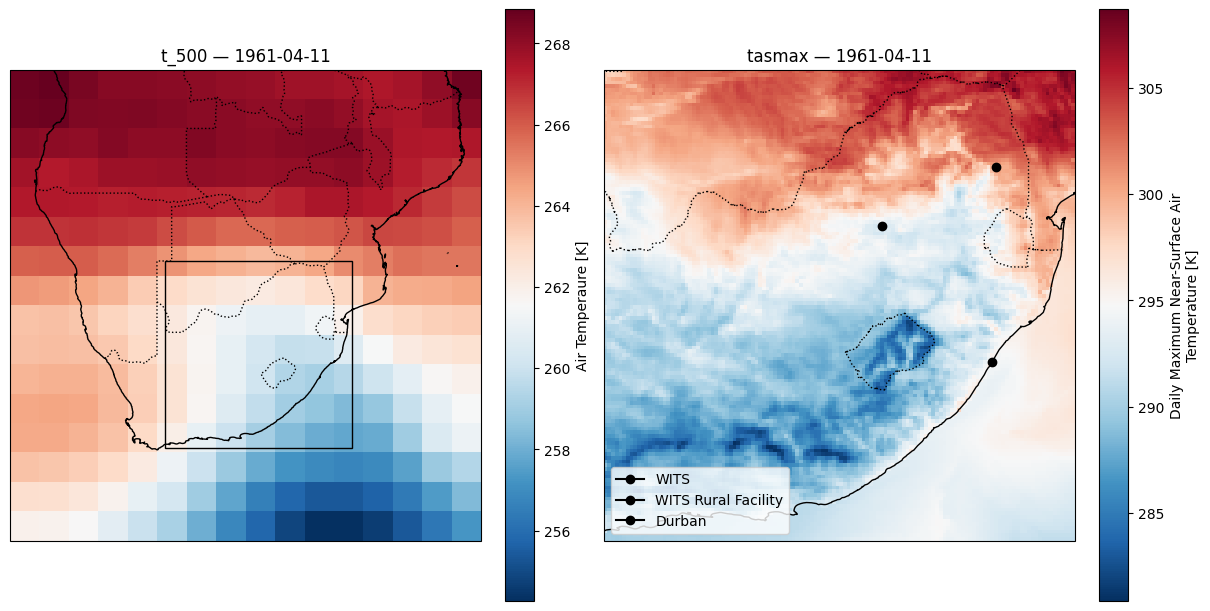

In [4]:
plot_predictor_and_target(
    ds_pred, ds_tgt,
    predictor='t_500',
    target='tasmax',
    time_index=100,
    cmap='RdBu_r',
    pinpoints={
        "WITS": (-26.19, 28.03),
        "WITS Rural Facility": (-24.57, 31.10),
        "Durban": (-29.86, 31.02),
    },
)

### 1.2 Train, validation and test split

We split the data into three non-overlapping sets by year:
- Training: used to learn the model weights
- Validation: used to monitor performance during training to select the best model and prevent overfitting
- Test: held out until after training, so the model has not seen this data. Used for final evaluation

In [5]:
# Select years for training, validation and testing (does not need to be consecutive years)
train_years = [
    *range(1961,1967),
    *range(1968,1975),
    *range(1976,1979),
    *range(2081,2087),
    *range(2088,2095),
    *range(2096,2099),
]
val_years = [1967, 1975, 2087, 2095]
test_years = [1979, 1980, 2080, 2099]

In [6]:
# Specify directories where the split data will be stord
train_dir = pathlib.Path('/gws/nopw/j04/mohc_shared/users/jar212/cordexbench/train')
train_dir.mkdir(parents=True, exist_ok=True)

predictors_train_data_path = train_dir / 'predictors_train.nc'
predictors_val_data_path = train_dir / 'predictors_val.nc'
predictors_test_data_path = train_dir / 'predictors_test.nc'
targets_train_data_path = train_dir / 'targets_train.nc'
targets_val_data_path = train_dir / 'targets_val.nc'
targets_test_data_path = train_dir / 'targets_test.nc'

In [7]:
# Split predictors and target datasets into train, val and test splits and save

def split_by_year(ds, years):
    return ds.sel(time=ds['time'].dt.year.isin(years))

ds_pred_train = split_by_year(ds_pred, train_years)
ds_pred_val = split_by_year(ds_pred, val_years)
ds_pred_test = split_by_year(ds_pred, test_years)
ds_tgt_train = split_by_year(ds_tgt, train_years)
ds_tgt_val = split_by_year(ds_tgt, val_years)
ds_tgt_test = split_by_year(ds_tgt, test_years)

ds_pred_train.to_netcdf(predictors_train_data_path)
ds_pred_val.to_netcdf(predictors_val_data_path)
ds_pred_test.to_netcdf(predictors_test_data_path)
ds_tgt_train.to_netcdf(targets_train_data_path)
ds_tgt_val.to_netcdf(targets_val_data_path)
ds_tgt_test.to_netcdf(targets_test_data_path)

ds_pred.close()
ds_tgt.close()

### 1.3 Output directory

We create an output directory to store the normalisation stats (used to transform data before inputing into the model and for converting model outputs back to physical units), the trained model weights and predictions made during inference.

In [8]:
# Specify directory where outputs will be stored (normalisation stats, alphas, betas, model)
output_dir = pathlib.Path('/gws/nopw/j04/mohc_shared/users/jar212/cordexbench/outputs')
output_dir.mkdir(parents=True, exist_ok=True)

normalisation_stats_path = output_dir / 'normalisation_stats.json'

### 1.4 Predictor and target selection

We select from 15 atmospheric fields across three pressure levels (500, 700 and 850 hPa): zonal wind (u), meridonal wind (v), specific humidity (q), temperature (t) and geopotential (z).

The target is chosen between precipitaion (pr) and near surface maximum temperature (tasmax).

In [9]:
# Select predictors and targets
predictors_selection = [
    'u_500', 'v_500', 'q_500', 't_500', 'z_500',
    'u_700', 'v_700', 'q_700', 't_700', 'z_700',
    'u_850', 'v_850', 'q_850', 't_850', 'z_850',
]
target_selection = ['tasmax']

### 1.5 Device

We use a GPU if available, which significantly speads up training.

In [10]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda:0


## 2. Dataset

The 'CordexDataset' class handles loading, preprocessing and normalisation of the predictor and target fields. It returns normalised tensors ready for input to the model.

Predictors are normalised at each time step (each 2D field has its spatial mean subtracted and is divided by its spatial standard deviation). This removes the day-to-day variation in the predictor fields and allows the model to foucs on spatial patterns rather than absolute values.

The day-to-day variation is captured through those spatial means and standard deviations. Together with a seasonal indicator, they make up the 1D inputs into the model. This 1D input is again normalised, using the mean and standard deviation of each 1D variable calculated over the entire training dataset.

We don't perform any normalisation for the target if it's precipitation. However, tasmax is given in Kelvin, so it is beneficial to perform some kind of normalisation (otherwise the model will spend a long time learning to increase the absolute value of the predictions instead of learning actual structure). We z-score normalise tasmax using the global mean and std over the whole training dataset.

The dataset also provides a 'denomalise()' method which inverts the normalisation at inference time, returing predictions in physical units (deg C for tasmax, mm/day for pr)

In [11]:
# Variables stored in Kelvin that are converted to Celsius in denormalise().
_KELVIN_TARGETS = frozenset({"tasmax"})

_KELVIN_TO_CELSIUS = 273.15

class CORDEXDataset(torch.utils.data.Dataset):
    """CORDEXBench: A benchmarking dataset for regional climate downscaling.

    Two normalisation strategies are applied depending on the target variable:
        - tasmax: z-score normalised with global mean and std over entire trainig dataset
        - pr: no normalisation: the model operated on mm/day values.

    Attributes:
        num_samples (int): Total number of samples in the dataset.
        grid_latitude_pred (xr.DataArray): Latitude coordinates of the predictors grid.
        grid_longitude_pred (xr.DataArray): Longitude coordinates of the predictors grid.
        grid_latitude_tgt (xr.DataArray): Latitude coordinates of the targets grid.
        grid_longitude_tgt (xr.DataArray): Longitude coordinates of the targets grid.
        time (pd.DatetimeIndex): Time coordinates.
        normalised_two_d_predictors (np.ndarray): Normalised 2D predictors,
            shape (num_samples, channels, lat, lon).
        normalised_one_d_predictors (np.ndarray): Normalised 1D predictors,
            shape (num_samples, num_1d_features).
        target_field (np.ndarray | None): Normalised target field,
            shape (num_samples, channels, lat, lon), or None if no target path provided.
        num_2d_predictors (int): Number of 2D predictor fields.
        num_1d_predictors (int): Number of 1D predictor variables.
    """

    def __init__(
        self,
        predictors_data_path: str,
        predictors: list[str],
        target: list[str],
        normalisation_stats_path: str | None = None,
        targets_data_path: str | None = None,
        is_train: bool = False,
    ):
        """Initialise CORDEX Benchmark dataset.

        If loading a dataset for training, normalisation statistics are computed over the
        training period and saved to a JSON file. If loading a dataset for validation or
        testing, normalisation statistics are loaded from that JSON file.

        Args:
            predictors_data_path: Path to netCDF data file for predictors.
            predictors: List of predictor field names, e.g. ["u_500", "t_850"].
            target: List of target field names, e.g. ["pr"] or ["tasmax"].
            normalisation_stats_path: Path to JSON file for storing/loading normalisation
                statistics. Required when is_train=False.
            targets_data_path: Path to netCDF data file for the target. If not provided,
                torch.tensor(float("nan")) is returned as the target from __getitem__.
            is_train: Whether the dataset is for training. If True, normalisation
                statistics are computed and saved to normalisation_stats_path.

        Raises:
            ValueError: If time coordinates do not match between predictors and targets.
            ValueError: If normalisation_stats_path is not provided when is_train=False.
            ValueError: If predictors differ from those used to compute normalisation stats.
        """
        super().__init__()

        self._target = target

        # Load predictors and targets
        with xr.open_dataset(predictors_data_path, engine="netcdf4") as ds_pred:
            two_d_predictors = np.stack(
                [ds_pred[predictor].values for predictor in predictors], axis=-1
            )  # (sample, lat, lon, channels)
            predictors_time = ds_pred["time"]
            self.grid_longitude_pred = ds_pred["lon"]
            self.grid_latitude_pred = ds_pred["lat"]

        if targets_data_path is not None:
            with xr.open_dataset(targets_data_path, engine="netcdf4") as ds_tgt:
                target_field = np.stack(
                    [ds_tgt[tgt].values for tgt in target], axis=-1
                )  # (sample, lat, lon, channels)
                targets_time = ds_tgt["time"]
                self.grid_latitude_tgt = ds_tgt["lat"]
                self.grid_longitude_tgt = ds_tgt["lon"]

            if not np.array_equal(predictors_time.values, targets_time.values):
                raise ValueError(
                    "Time coordinates do not match between predictors and targets files."
                )
        else:
            target_field = None

        self.time = pd.to_datetime(predictors_time)
        self.num_samples = two_d_predictors.shape[0]

        # Normalise 2D predictors (per-sample spatial z-score)
        normalised_two_d_predictors = (
            two_d_predictors - np.mean(two_d_predictors, axis=(1, 2), keepdims=True)
        ) / np.std(two_d_predictors, axis=(1, 2), keepdims=True)
        self.normalised_two_d_predictors = einops.rearrange(
            normalised_two_d_predictors, "sample lat lon channels -> sample channels lat lon"
        )
        self._num_2d_predictors = self.normalised_two_d_predictors.shape[1]


        # Build 1D predictors (seasonal indication, spatial means and stds of each 2d predictor)
        day_of_year = self.time.dayofyear
        seasonal_indicator = np.stack(
            [
                np.sin(2 * np.pi * day_of_year / 365),
                np.cos(2 * np.pi * day_of_year / 365),
            ],
            axis=-1,
        )  # (sample, 2)
        two_d_predictor_spatial_means = np.mean(two_d_predictors, axis=(1, 2))  # (sample, channels)
        two_d_predictor_spatial_stds = np.std(two_d_predictors, axis=(1, 2))    # (sample, channels)
        one_d_predictors = np.concatenate(
            [two_d_predictor_spatial_means, two_d_predictor_spatial_stds, seasonal_indicator],
            axis=-1,
        )  # (sample, num_1d_features)


        # Normalisation statistics (computed on train, loaded on val/test)
        if is_train:
            normalisation_stats = self._compute_normalisation_stats(
                predictors=predictors,
                one_d_predictors=one_d_predictors,
                target_field=target_field,
            )
            if normalisation_stats_path is not None:
                with open(normalisation_stats_path, "w") as f:
                    json.dump(normalisation_stats, f, indent=4)
        else:
            if normalisation_stats_path is None:
                raise ValueError(
                    "Must provide normalisation_stats_path when is_train=False."
                )
            with open(normalisation_stats_path, "r") as f:
                normalisation_stats = json.load(f)

            if normalisation_stats["metadata"]["predictors"] != predictors:
                raise ValueError(
                    f"Predictors in normalisation file "
                    f"({normalisation_stats['metadata']['predictors']}) differ from "
                    f"those requested ({predictors})."
                )

        self._normalisation_stats = normalisation_stats

        # Apply 1D predictor normalisation using training-period statisitcs
        one_d_means = np.array(normalisation_stats["predictor_1d_means"])
        one_d_stds = np.array(normalisation_stats["predictor_1d_stds"])
        self.normalised_one_d_predictors = (one_d_predictors - one_d_means) / one_d_stds
        self._num_1d_predictors = self.normalised_one_d_predictors.shape[1]


        # Apply target normalisation
        self.target_field = (
            self._normalise_target(target_field, normalisation_stats)
            if target_field is not None
            else None
        )


    # Private helper functions
    def _compute_normalisation_stats(
        self,
        predictors: list[str],
        one_d_predictors: np.ndarray,
        target_field: np.ndarray | None,
    ) -> dict:
        """Compute normalisation statistics over the training period.

        Args:
            predictors: List of predictor field names.
            one_d_predictors: shape (sample, num_1d_features).
            target_field: shape (sample, lat, lon, channels), or None.

        Returns:
            Normalisation statistics dict
        """
        stats: dict = {
            "predictor_1d_means": np.mean(one_d_predictors, axis=0).tolist(),
            "predictor_1d_stds": np.std(one_d_predictors, axis=0).tolist(),
            "metadata": {"predictors": predictors, "target": self._target},
            "target_mean": {}, # mean for tasmax, 0 for pr
            "target_std": {}, # std for tasmax, 1 for pr
        }

        if target_field is not None:
            for ch_idx, name in enumerate(self._target):
                channel = target_field[:, :, :, ch_idx].astype(np.float64)
                if name in _KELVIN_TARGETS:
                    stats["target_mean"][name] = float(np.mean(channel))
                    stats["target_std"][name] = float(np.std(channel))
                else:
                    # identity transform (no normalisation applied)
                    stats["target_mean"][name] = 0.0
                    stats["target_std"][name] = 1.0

        return stats

    def _normalise_target(
        self,
        target_field: np.ndarray,
        normalisation_stats: dict,
    ) -> np.ndarray:
        """Apply per-channel normalisation to the target field.

        Args:
            target_field: Raw target array, shape (sample, lat, lon, channels).
            normalisation_stats: Dict as produced by _compute_normalisation_stats.

        Returns:
            Normalised array, shape (sample, channels, lat, lon).
        """
        mean = normalisation_stats["target_mean"]
        std = normalisation_stats["target_std"]

        normalised = target_field.copy().astype(np.float32)
        for ch_idx, name in enumerate(self._target):
            normalised[:, :, :, ch_idx] = (normalised[:, :, :, ch_idx] - mean[name]) / std[name]

        return einops.rearrange(normalised, "sample lat lon channels -> sample channels lat lon")


    # Public helper function to  denormalsie predicitons (used in inference)
    def denormalise(
        self,
        prediction: np.ndarray | torch.Tensor,
    ) -> np.ndarray:
        """Invert target normalisation, returning values in physical units.

        For tasmax: inverts z-score normalisation then converts Kelvin to deg C
        For pr: returns values unchanged

        Args:
            prediction: Normalised model output, shape (..., channels, lat, lon).

        Returns:
            np.ndarray in physical units (Celsius for temperature, mm/day for pr),
            same shape as input.
        """
        if isinstance(prediction, torch.Tensor):
            prediction = prediction.numpy()

        mean = self._normalisation_stats["target_mean"]
        std = self._normalisation_stats["target_std"]

        out = prediction.copy().astype(np.float64)
        for ch_idx, name in enumerate(self._target):
            channel = out[..., ch_idx, :, :]
            channel = channel * std[name] + mean[name]
            if name in _KELVIN_TARGETS:
                channel = channel - _KELVIN_TO_CELSIUS
            out[..., ch_idx, :, :] = channel

        return out

    @property
    def num_2d_predictors(self) -> int:
        """Return the number of 2D predictor fields."""
        return self._num_2d_predictors

    @property
    def num_1d_predictors(self) -> int:
        """Return the number of 1D predictor variables."""
        return self._num_1d_predictors

    def __len__(self) -> int:
        """Return number of samples in dataset."""
        return self.num_samples

    def __getitem__(self, idx) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, str]:
        """Return sample at index `idx`.

        Returns:
            two_d_predictors: Normalised 2D predictors, shape (channels, lat, lon).
            one_d_predictors: Normalised 1D predictors, shape (num_1d_features,).
            target: Normalised target field, shape (channels, lat, lon), or
                torch.tensor(float("nan")) if no targets_data_path was provided.
            time: Date string in "YYYY-MM-DD" format.
        """
        two_d_predictors = torch.tensor(
            self.normalised_two_d_predictors[idx], dtype=torch.float32
        )
        one_d_predictors = torch.tensor(
            self.normalised_one_d_predictors[idx], dtype=torch.float32
        )
        target = (
            torch.tensor(self.target_field[idx], dtype=torch.float32)
            if self.target_field is not None
            else torch.tensor(float("nan"))
        )
        time = self.time[idx].strftime("%Y-%m-%d")
        return two_d_predictors, one_d_predictors, target, time

### 2.1 Create datasets

We create separate dataset objects for training and validation. Note that 'is_train=True' is only set for the training dataset - this triggers computation of the normaliation statistics over the training period, which are saved to a JSON file in the 'output_dir'. The validation dataset loads these same statiscts to ensure it is normliased conssistently with the training data.

In [12]:
training_dataset = CORDEXDataset(
    predictors_data_path=predictors_train_data_path,
    predictors=predictors_selection,
    target=target_selection,
    normalisation_stats_path=normalisation_stats_path,
    targets_data_path=targets_train_data_path,
    is_train=True,
)

validation_dataset = CORDEXDataset(
    predictors_data_path=predictors_val_data_path,
    predictors=predictors_selection,
    target=target_selection,
    normalisation_stats_path=normalisation_stats_path,
    targets_data_path=targets_val_data_path,
    is_train=False,
)

print(f"Training samples:       {len(training_dataset)}")
print(f"Validation samples:     {len(validation_dataset)}")
print(f"2D predictors:          {training_dataset.num_2d_predictors}")
print(f"1D predictors:          {training_dataset.num_1d_predictors}")
print(f"Predictor grid shape:   {training_dataset.normalised_two_d_predictors.shape[2:]}")
print(f"Target grid shape:      {training_dataset.target_field.shape[2:]}")

Training samples:       11680
Validation samples:     1460
2D predictors:          15
1D predictors:          32
Predictor grid shape:   (16, 16)
Target grid shape:      (128, 128)


### 2.2 Create dataloaders

PyTorch 'DataLoader' objects handle batching and shuffling of the data during training. We shuffle the training data each epoch so the model does not learn the order of the samples. The validation datalaoder is not shuffled.

In [13]:
batch_size = 32

In [14]:
training_dataloader = torch.utils.data.DataLoader(training_dataset, batch_size=batch_size, shuffle=True)
validation_dataloader = torch.utils.data.DataLoader(validation_dataset, batch_size=batch_size)

## 3. Model

The UNet takes the normalised 2D preditor fields and 1D predictors as inputs and produces a high-resolution output field. The hyperparameters below control the model architecture and training procedure

In [15]:
# Model and training hyperparameters
model_channels = 64
channel_mult = [1, 2, 4, 8, 8]
loss = 'mse' # 'mse', 'mae', or 'emulasym'
optimiser_type = 'adam' # 'adam' or 'sgd'
learning_rate = 5e-4
scheduler_type = 'onecycle' # 'onecycle' or 'steplr'
epochs = 10

# StepLR scheduler parameters (only used if scheduler_type = 'steplr')
scheduler_step_size = 10
scheduler_gamma = 0.1

# Peak learning rate for onecycle scheduler
scheduler_max_lr = 5e-4

# Inferred from data - do not change
input_resolution = training_dataset.normalised_two_d_predictors.shape[-1]
output_resolution = training_dataset.target_field.shape[-1]
output_channels = len(target_selection)
num_2d_predictors = training_dataset.num_2d_predictors
num_1d_predictors = training_dataset.num_1d_predictors

### 3.1 UNet building blocks

The UNet is assembled from five building blocks defined below:
- ConvBlock: two convolutional layers each followed by batch normalisation and ReLU. This is used to increase the number of feature channels in the top layer of the UNet.
- DownBlock: halves the spatial resolution using max pooling, then applied a convolution. Used in the encoder path to progressively compress the input.
- FullyConnectedBlock: processes the 1D predictors (spatial means, stds and seasonal indicator) for embedding in the bottle neck of the UNet
- UpBlock: doubles the spatial resolution using a transposed convolution. Afterwards, the UNet concatenates the encoder features before applying a convolution. This preserves the fine-scale spatial information from the encoder.
- ConvTransposeBlock: Increases the spatial resolution of the output to the required output resolution.
- Conv1x1: a single 1x1 convolution used as the final layer of the network to map from the internal channel dimension to the number of output channels.

In [16]:
class ConvBlock(nn.Module):
    """Convolutional block with two convolutional layers and batch normalisation."""

    def __init__(self, in_ch: int, out_ch: int):
        """Initialise the ConvBlock.

        Args:
            in_ch: Number of input channels.
            out_ch: Number of output channels
        """
        kernel_size = 3
        stride = 1
        padding = 1

        super().__init__()

        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor. Shape: (batch_size, in_ch, h, w)

        Returns:
            Output tensor. Shape: (batch_size, out_ch, h, w)
        """
        return self.model(x)

In [17]:
class DownBlock(nn.Module):
    """Downsampling block.

    Uses a max pooling layer to half the spatial dimensions of the input.
    """

    def __init__(self, in_ch: int, out_ch: int):
        """Initialise the DownBlock.

        Args:
            in_ch: Number of input channels.
            out_ch: Number of output channels.
        """
        kernel_size = 3
        stride = 1
        padding = 1

        super().__init__()

        layers = [
            nn.MaxPool2d(2),
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor. Shape: (batch_size, in_ch, h, w)

        Returns:
            Output tensor. Shape: (batch_size, out_ch, h/2, w/2)
        """
        return self.model(x)

In [18]:
class FullyConnectedBlock(nn.Module):
    """Block with four fully connected layers."""

    def __init__(self, in_features: int, out_features: int):
        """Initialise the FullyConnectedBlock.

        Args:
            in_features: Number of input features.
            out_features: Number of output features.
        """
        super().__init__()

        layers = [
            nn.Linear(in_features, 64),
            nn.Linear(64, 128),
            nn.Linear(128, 256),
            nn.Linear(256, out_features),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: Tensor of shape (batch_size, in_features)

        Returns:
            Tensor of shape (batch_size, out_features)
        """
        return self.model(x)

In [19]:
class UpBlock(nn.Module):
    """Upsampling block.

    Uses a transposed convolutional layer to double the spatial dimensions of the input.
    """

    def __init__(self, in_ch: int, out_ch: int):
        """Initialise the UpBlock.

        Args:
            in_ch: Number of input channels.
            out_ch: Number of output channels. This is required to be half the number of input
                channels.

        Raises:
            ValueError: If the number of output channels is not half the number of input channels.
        """
        if out_ch != in_ch / 2:
            raise ValueError("Number of output channels must be half the number of input channels")

        # Convolution variables
        kernel_size = 3
        stride = 1
        padding = 1

        # Transposed convolution variables
        strideT = 2
        out_paddingT = 1

        super().__init__()

        convT_layers = [
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size, strideT, padding, out_paddingT),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        ]
        self.convT = nn.Sequential(*convT_layers)

        conv_layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        ]
        self.conv = nn.Sequential(*conv_layers)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor. Shape: (batch_size, in_ch, h, w)
            skip: Skip connection tensor. Typically an output from a downsampling block.
                Shape: (batch_size, in_ch / 2, h*2, w*2)

        Returns:
            Output tensor. Shape: (batch_size, in_ch / 2, h*2, w*2)
        """
        x = self.convT(x)
        x = torch.cat((x, skip), dim=1)
        x = self.conv(x)
        return x

In [20]:
class ConvTransposeBlock(nn.Module):
    """Transposed convolutional block with a convolutional layer, batch normalisation and ReLU.

    The transposed convolutional layer doubles the spatial dimensions of the input.
    """

    def __init__(self, in_ch: int, out_ch: int):
        """Initialise the ConvTransposeBlock.

        Args:
            in_ch: Number of input channels.
            out_ch: Number of output channels.
        """
        kernel_size = 3
        stride = 2
        padding = 1
        output_padding = 1

        super().__init__()

        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size, stride, padding, output_padding),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor. Shape: (batch_size, in_ch, h, w)

        Returns:
            Output tensor. Shape: (batch_size, out_ch, 2*h, 2*w)
        """
        return self.model(x)

In [21]:
class Conv1x1(nn.Module):
    """1x1 convolutional layer mapping from encoder channels to output channels.
    
    No activation is applied — this is the final layer of the network and the
    output range is unconstrained.
    """

    def __init__(self, in_ch: int, out_ch: int):
        """Initialise Conv1x1.

        Args:
            in_ch: Number of input channels.
            out_ch: Number of output channels.
        """
        super().__init__()
        self.model = nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=1, padding=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            x: Input tensor, shape (batch, in_ch, h, w).

        Returns:
            Output tensor, shape (batch, out_ch, h, w).
        """
        return self.model(x)

In [22]:
# class Conv1x1(nn.Module):
#     """1x1 convolutional layer with ReLU activation."""

#     def __init__(self, in_ch: int, out_ch: int):
#         """Initialise the Conv1x1 layer.

#         Args:
#             in_ch: Number of input channels.
#             out_ch: Number of output channels
#         """
#         kernel_size = 1
#         stride = 1
#         padding = 0

#         super().__init__()

#         self.layers = [
#             nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding),
#             nn.ReLU(),
#         ]
#         self.model = nn.Sequential(*self.layers)

#     def forward(self, x: torch.Tensor) -> torch.Tensor:
#         """Forward pass.

#         Args:
#             x: Input tensor. Shape: (batch_size, in_ch, h, w)

#         Returns:
#             Output tensor. Shape: (batch_size, out_ch, h, w)
#         """
#         return self.model(x)

### 3.2 UNet

The full UNet has three main components:
- Encoder: progressively donwscamples the 2D predictor fields through a series of DownBlocks, halving the sptial resolution at each levbel until reachign a 1x1 bottleneck. The number of feature channels increases at each level, controlled by 'channel_mult'
- Bottleneck: the 1D predictors are passed through a fully connected embedding and injected here by concatenating with the encoder output. This gives the model information aabout the large-scale daily state and time of year at the point of macimu msptial compression.
- Decoder: progressively upsamples back towards the input resolution using UpBlocks, with skip connections from the corresponding encoder level concatenated at each step to recover spatial detal. A final sequence of transposed convolutions blocks then brings the output form the input resolution (16x16) up to the target resolution (128x128), followed by a 1x1 convolution to produce the outpiut field.

In [23]:
class UNet(nn.Module):
    """U-net model."""

    def __init__(
        self,
        num_2d_predictors: int,
        num_1d_predictors: int,
        model_channels: int = 64,
        channel_mult: list[int] = [1, 2, 4, 8, 8],
        input_resolution: int = 16,
        output_resolution: int = 64,
        output_channels: int = 1,
    ):
        """Initialise the U-net model.

        Args:
            num_2d_predictors: Number of 2D predictor fields.
            num_1d_predictors: Number of 1D predictor features.
            model_channels: Base multiplier for the number of channels.
            channel_mult: Per-resolution multipliers for the number of channels. These must
                increase by a factor of 2 for each resolution level, except for the last
                resolution level which must be the same as the previous one.
            input_resolution: Resolution of the input data.
            output_resolution: Required resolution of the output. The ratio
                output_resolution/input_resolution must be a power of 2. If the output resolution
                differs from the input resolution, then a sequence of convolution and transposed
                convolution blocks will be used to upsample the output from the decoder to the
                required output resolution. Doury et al (2022) uses input_resolution=16 and
                output_resolution=128.
            output_channels: Required number of channels in the output.

        Raises:
            ValueError: If output_resolution isn't a multiple of resolution.
        """
        super().__init__()
        channels = [model_channels * mult for mult in channel_mult]

        # MLP embedding for the 1D predictors
        self.embedding = FullyConnectedBlock(
            in_features=num_1d_predictors, out_features=channels[-1]
        )

        # Encoder
        self.encoder = torch.nn.ModuleDict()
        for level, num_channels in enumerate(channels):
            res = input_resolution >> level  # Equivalent to input_resolution // (2 ** level)
            if level == 0:
                in_ch = num_2d_predictors
                out_ch = num_channels
                self.encoder[f"{res}x{res}_conv"] = nn.Sequential(
                    ConvBlock(in_ch, int(out_ch / 2)), ConvBlock(int(out_ch / 2), out_ch)
                )
            else:
                in_ch = out_ch
                out_ch = num_channels
                self.encoder[f"{res}x{res}_down"] = DownBlock(in_ch, out_ch)

        if res != 1:
            raise ValueError(f"Bottleneck layer must be 1x1 spatially. Got {res}x{res}")

        # Decoder
        self.decoder = torch.nn.ModuleDict()
        for level, num_channels in reversed(list(enumerate(channels[:-1]))):
            res = input_resolution >> level
            in_ch = num_channels * 2
            out_ch = num_channels
            self.decoder[f"{res}x{res}_up"] = UpBlock(in_ch, out_ch)

        # Upsample output of decoder to required output resolution.
        scale = output_resolution / input_resolution
        if not scale.is_integer():
            raise ValueError("output_resolution must be divisible by resolution")
        scale = int(scale)
        if scale & (scale - 1) != 0:  # Check if scale is a power of 2
            raise ValueError("output_resolution/resolution must be a power of 2")
        num_upsample_steps = int(log2(scale))

        upsample_layers: list[nn.Module] = []
        for _ in range(num_upsample_steps):
            upsample_layers.append(ConvTransposeBlock(in_ch=channels[0], out_ch=channels[0]))
            upsample_layers.append(ConvBlock(in_ch=channels[0], out_ch=channels[0]))
        upsample_layers.append(Conv1x1(in_ch=channels[0], out_ch=output_channels))
        self.upsample = nn.Sequential(*upsample_layers)

    def forward(self, two_d_fields: torch.Tensor, one_d_features: torch.Tensor) -> torch.Tensor:
        """Forward pass.

        Args:
            two_d_fields: 2D predictor fields. Shape (batch_size, num_2d_predictors, h, w).
            one_d_features: 1D predictor features. Shape (batch_size, num_1d_predictors).

        Returns:
            x: Predicted 2D field. Shape (batch_size, output_channels, output_resolution, output_resolution)
        """
        x = two_d_fields

        # Encoder
        skips = []
        for idx, block in enumerate(self.encoder.values()):
            x = block(x)
            if idx < len(self.encoder) - 1:
                skips.append(x)

        embedded_1d_features = self.embedding(one_d_features)  # shape: (batch_size, C)
        # Assumes bottleneck layer is 1x1 spatially
        embedded_1d_features = embedded_1d_features[
            :, :, None, None
        ]  # shape: (batch_size, C, 1, 1)

        x = torch.cat((x, embedded_1d_features), dim=1)  # shape: (batch_size, C*2, 1, 1)

        # Decoder
        for block in self.decoder.values():
            x = block(x, skips.pop())

        # Upsample output of encoder-decoder to required output resolution
        x = self.upsample(
            x
        )  # shape: (batch_size, output_channels, output_resolution, output_resolution)

        return x

### 3.3 Initialise the model

initialise the model and move it to the device. We print the number parameters the model will be trying to learn during training.

In [24]:
model = UNet(
    num_2d_predictors=num_2d_predictors,
    num_1d_predictors=num_1d_predictors,
    model_channels=model_channels,
    channel_mult=channel_mult,
    input_resolution=input_resolution,
    output_resolution=output_resolution,
    output_channels=output_channels,
).to(DEVICE)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

Model parameters: 22,489,441


## 4. Loss functions

For precipitation, we use the 'EmulASYM' loss function, which combines MAE with an asymmetric penalty term that increases the penalty for underpredicting heavy rainfall events. For temperature we use standard MSE or MAE (and the following two code blocks do no apply).

The total loss is the mean loss over all grid cells and all samples in the batch.

### 4.1 Asymmetric loss function (precipitation only)

We fit a gamma distribution to the wet-day (>1mm/day) precipitation at each grid cell over the training period. This gives a spatial map of alpha (shape) and beta (scale) parameters that describe the local precipitation climatology.
This allows the loss to take into consideration how extreme a rainfall event is in the context of its location (if it is very rare for a particular grid cell to receive high rainall, the higher the penalty for missing a high rainfall event).

The loss is then the mean absolute error plus this assymmetric penalty term. See the references for more details

In [25]:
def fit_gamma_distributions(
    precip_data: np.ndarray,
    time: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Fit gamma distributions to precipitation data, one per grid cell.

    A gamma distribution is fitted to the wet-day precipitation (> 1mm) for each
    grid cell. Distributions are fitted independently for each year and the resulting
    alpha and beta parameters are averaged over all years.

    Grid cells with no wet days in a given year are assigned shape=1, scale=1
    (an exponential distribution), which acts as a neutral fallback.

    Years with fewer than 360 samples are skipped, as an incomplete year would bias
    the fitted distributions.

    Note: fitting is performed in a grid-cell loop because scipy.stats.gamma.fit
    does not support vectorised fitting across multiple samples simultaneously.

    Args:
        precip_data: Precipitation data, shape (samples, lat, lon), in mm/day.
        time: Time coordinates, shape (samples,).

    Returns:
        alphas: Alpha (shape) parameters for each grid cell, shape (lat, lon).
        betas: Beta (scale) parameters for each grid cell, shape (lat, lon).
    """
    num_lat, num_lon = precip_data.shape[1], precip_data.shape[2]
    alpha_grids: list[np.ndarray] = []
    beta_grids: list[np.ndarray] = []

    years = np.unique([t.year for t in time])
    for year in years:
        idxs = np.where([t.year == year for t in time])[0]
        if len(idxs) < 360:
            warnings.warn(
                f"Skipping year {year}: only {len(idxs)} samples available (expected >= 360)."
            )
            continue

        samples = precip_data[idxs]  # (days_in_year, lat, lon)
        alpha_grid = np.zeros((num_lat, num_lon))
        beta_grid = np.zeros((num_lat, num_lon))

        for i in range(num_lat):
            for j in range(num_lon):
                data = samples[:, i, j]
                data = data[data > 1]
                if len(data) == 0:
                    alpha_grid[i, j] = 1.0
                    beta_grid[i, j] = 1.0
                else:
                    shape, _, scale = gamma.fit(data, floc=0)
                    alpha_grid[i, j] = shape
                    beta_grid[i, j] = scale

        alpha_grids.append(alpha_grid)
        beta_grids.append(beta_grid)

    alphas = np.mean(alpha_grids, axis=0)
    betas = np.mean(beta_grids, axis=0)
    return alphas, betas

In [26]:
class EmulASYMLoss(torch.nn.Module):
    """Asymmetric loss function for precipitation downscaling.

    Combines MAE with an asymmetric penalty term that increasingly penalises
    underprediction of heavy rainfall events. The penalty is weighted by the
    squared gamma CDF of the target value, so rare high-rainfall events incur
    a much larger penalty than common low-rainfall days.

    The gamma CDF is evaluated on physical precipitation values (mm/day), so
    inputs and targets are denormalised internally before computing the asymmetric
    term. The MAE is computed in normalised space, consistent with how MSE/MAE
    losses operate during training.

    Total loss = MAE(normalised) + mean(CDF(target_mm/day)^2 * max(0, target - prediction))
    """

    def __init__(
        self,
        alphas: torch.Tensor | np.ndarray,
        betas: torch.Tensor | np.ndarray,
        pr_channel_idx: int,
    ):
        """Initialise EmulASYM loss.

        Args:
            alphas: Gamma shape parameters per grid cell, shape (lat, lon).
            betas: Gamma scale parameters per grid cell, shape (lat, lon).
            pr_channel_idx: Index of the pr channel in the target tensor.
            pr_norm_mean: Mean used to normalise pr during dataset construction
                (after log1p transform).
            pr_norm_std: Std used to normalise pr during dataset construction
                (after log1p transform).
        """
        super().__init__()
        if isinstance(alphas, np.ndarray):
            alphas = torch.from_numpy(alphas).float()
        if isinstance(betas, np.ndarray):
            betas = torch.from_numpy(betas).float()
        # Register as buffers so they are moved to the correct device with .to(DEVICE)
        # and included in state_dict for checkpointing.
        self.register_buffer("alphas", alphas)
        self.register_buffer("betas", betas)
        self.pr_channel_idx = pr_channel_idx

    def forward(self, input: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        """Compute EmulASYM loss.

        Args:
            input: Predicted field, shape (batch, channels, lat, lon).
            target: Target field, shape (batch, channels, lat, lon).

        Returns:
            Scalar loss tensor.
        """
        mae_loss = F.l1_loss(input, target)

        # Extract pr channel and denormalise to mm/day for CDF evaluation
        pr_input  = input[:, self.pr_channel_idx, :, :]   # (batch, lat, lon)
        pr_target = target[:, self.pr_channel_idx, :, :]  # (batch, lat, lon)

        gamma_cdf = torch.special.gammainc(self.alphas, pr_target / self.betas)
        asym_loss = (gamma_cdf ** 2 * torch.clamp(pr_target - pr_input, min=0)).mean()

        return mae_loss + asym_loss



### 4.2 Select loss function

In [27]:
if loss == "mse":
    loss_fn = torch.nn.MSELoss()
elif loss == "mae":
    loss_fn = torch.nn.L1Loss()
elif loss == "emulasym":
    if "pr" not in target_selection:
        raise ValueError(
            "EmulASYM loss requires 'pr' to be in target_selection."
        )
    # Fit gamma distributions on raw (un-normalised) precipitation in mm/day.
    # This must be done from the source netCDF, not training_dataset.target_field,
    # which has already been log1p normalised.
    with xr.open_dataset(targets_train_data_path) as ds_tgt_train:
        precip_data = ds_tgt_train["pr"].values  # (samples, lat, lon)
    alphas, betas = fit_gamma_distributions(precip_data, training_dataset.time)
    np.save(output_dir / 'alphas.npy', alphas)
    np.save(output_dir / 'betas.npy', betas)

    pr_channel_idx = target_selection.index("pr")
    loss_fn = EmulASYMLoss(
        alphas=alphas,
        betas=betas,
        pr_channel_idx=pr_channel_idx,
    ).to(DEVICE)
else:
    raise ValueError(
        f"Invalid loss function '{loss}'. Must be one of 'mse', 'mae', 'emulasym'."
    )


## 5. Training

### 5.1 Optimiser

The optimiser updates the model weights based on the gradients computed during backpropagation.

In [28]:
# Optimiser selection
if optimiser_type.lower() == "adam":
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
elif optimiser_type.lower() == "sgd":
    optimiser = torch.optim.SGD(model.parameters(), lr=learning_rate)
else:
    raise ValueError(f"Unsupported optimiser: {optimiser_type}")

### 5.2 learning rate scheduler

The learning rate scheduler adjusts the learning rate during training. We use OneCylerLr by default, which increases the learning rate from a low value to a prak and then decreases it again over the course of training. This helps the model escape local minima early in training and converge to a better solution.

In [29]:
# Scheduler selection
if scheduler_type.lower() == "onecycle":
    scheduler = OneCycleLR(
        optimiser,
        max_lr=scheduler_max_lr,
        steps_per_epoch=len(training_dataloader),
        epochs=epochs,
    )
elif scheduler_type.lower() == "steplr":
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimiser,
        step_size=scheduler_step_size,
        gamma=scheduler_gamma,
    )
else:
    raise ValueError(f"Unsupported scheduler: {scheduler_type}")

### 5.3 Training and validation loops

The trainig loop iterates over the trainig data in batches, computes the loss, backpropagates the gradients and updates the model weights. The test loop evaluates the model on the validation data without updataing the weights. Both batch loss and learning rate are logged to MLflow during training. (TODO: WHERE IS MLFLOW?? WHAT IS MLFLOW??? HOW DO I FIND THISS?)

In [30]:
def train_loop(
    dataloader: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler: torch.optim.lr_scheduler,
    device: torch.device,
    epoch: int,
    scheduler_type: str = "onecycle",
):
    """Training loop for a single epoch.

    Runs the training loop for a single epoch. Metrics are logged to MLflow.

    Args:
        dataloader: DataLoader for the training data.
        model: The model to train.
        loss_fn: The loss function.
        optimizer: The optimizer.
        scheduler: The learning rate scheduler.
        device: The device to run the training on.
        epoch: The current epoch.
        scheduler_type: Type of scheduler ('onecycle' or 'steplr').
    """
    num_samples = len(dataloader.dataset)
    num_batches = len(dataloader)

    # Set the model to training mode.
    model.train()

    for batch_idx, (two_d_predictors, one_d_predictors, target, _) in enumerate(dataloader):
        # Move data to the device.
        two_d_predictors = two_d_predictors.to(device)
        one_d_predictors = one_d_predictors.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        # Forward pass.
        output = model(two_d_predictors, one_d_predictors)

        # Compute the loss.
        loss = loss_fn(output, target)

        # Backward pass.
        loss.backward()

        # Update the weights.
        optimizer.step()

        # The learning rate for OneCycleLR should be stepped after each batch. 
        if scheduler_type.lower() == "onecycle":
            scheduler.step()

        if batch_idx % 100 == 0:
            loss = loss.item()
            current = batch_idx * len(two_d_predictors)
            print(f"loss: {loss:>7f}  [{current:>5d}/{num_samples:>5d}]")
            batch_number = (epoch * num_batches) + batch_idx
            mlflow.log_metric("Training loss", loss, step=batch_number)
            mlflow.log_metric("learning rate", scheduler.get_last_lr()[0], step=batch_number)

    # Step the learning rate for StepLR only (once per epoch)
    if scheduler_type.lower() == "steplr":
        scheduler.step()

In [31]:
def test_loop(
    dataloader: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    loss_fn: torch.nn.Module,
    device: torch.device,
    epoch: int,
) -> float:
    """Validation loop.

    Iterates over the validation/test data, computes predictions and loss.

    Args:
        dataloader: DataLoader for the validation/test data.
        model: The model to evaluate.
        loss_fn: The loss function.
        device: The device to run the evaluation on.
        epoch: The current epoch.

    Returns:
        The average loss over the validation/test dataset.
    """
    model.eval()
    num_batches = len(dataloader)
    test_loss = 0

    with torch.no_grad():
        for two_d_predictors, one_d_predictors, target, _ in dataloader:
            # Move data to the device.
            two_d_predictors = two_d_predictors.to(device)
            one_d_predictors = one_d_predictors.to(device)
            target = target.to(device)

            # Forward pass.
            output = model(two_d_predictors, one_d_predictors)

            # Compute the loss.
            loss = loss_fn(output, target)
            loss = loss.item()

            test_loss += loss

    test_loss /= num_batches

    print(f"\nValidation loss: {test_loss:>7f}\n")
    mlflow.log_metric("Validation loss", test_loss, step=epoch + 1)

    return test_loss

### 5.4 Train

We train the model for the specified epochs, saving the best model weights bases on validation loss (the weights are saved in 'output_dir'). The loss is printed for every 100 batches within an epoch, along with the validation loss and learning rate after each epoch.

In [32]:
best_val_loss = np.inf
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_loop(
        training_dataloader, model, loss_fn, optimiser, scheduler, DEVICE, epoch, scheduler_type
    )

    val_loss = test_loop(validation_dataloader, model, loss_fn, DEVICE, epoch)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

    if scheduler is not None:
        print(f"Current learning rate: {scheduler.get_last_lr()[0]}")

model_path = output_dir / 'model.pth'
print(f"Training complete. Saving model to {model_path}")
torch.save(best_model_state, model_path)

Epoch 1
-------------------------------
loss: 1.155231  [    0/11680]


2026/03/12 19:12:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/03/12 19:12:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/03/12 19:12:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/03/12 19:12:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/03/12 19:12:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/03/12 19:12:39 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/03/12 19:12:41 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/03/12 19:12:41 INFO alembic.runtime.migration: Will assume non-transactional DDL.


loss: 0.281686  [ 3200/11680]
loss: 0.211464  [ 6400/11680]
loss: 0.177477  [ 9600/11680]

Validation loss: 0.112964

Current learning rate: 0.00014019900917212663
Epoch 2
-------------------------------
loss: 0.112142  [    0/11680]
loss: 0.117864  [ 3200/11680]
loss: 0.106372  [ 6400/11680]
loss: 0.080121  [ 9600/11680]

Validation loss: 0.112906

Current learning rate: 0.0003803976883054983
Epoch 3
-------------------------------
loss: 0.258638  [    0/11680]
loss: 0.114024  [ 3200/11680]
loss: 0.078500  [ 6400/11680]
loss: 0.096690  [ 9600/11680]

Validation loss: 0.068316

Current learning rate: 0.0004999998110155123
Epoch 4
-------------------------------
loss: 0.100576  [    0/11680]
loss: 0.162648  [ 3200/11680]
loss: 0.089767  [ 6400/11680]
loss: 0.078310  [ 9600/11680]

Validation loss: 0.062027

Current learning rate: 0.0004751087719439071
Epoch 5
-------------------------------
loss: 0.063879  [    0/11680]
loss: 0.131316  [ 3200/11680]
loss: 0.241863  [ 6400/11680]
loss: 0

## 6. Inference

We now run the trained model on the test dataset to generate predictions. The test data covers years that were held out during training and validation, giving an unbviased estimate of model performance.

### 6.1 Load model

Initialised the UNet and load the saved weights from the best training checkpoint. The architecture hyperparameters must match those used in training.

In [33]:
model = UNet(
    num_2d_predictors=num_2d_predictors,
    num_1d_predictors=num_1d_predictors,
    model_channels=model_channels,
    channel_mult=channel_mult,
    input_resolution=input_resolution,
    output_resolution=output_resolution,
    output_channels=output_channels,
).to(DEVICE)
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

UNet(
  (embedding): FullyConnectedBlock(
    (model): Sequential(
      (0): Linear(in_features=32, out_features=64, bias=True)
      (1): Linear(in_features=64, out_features=128, bias=True)
      (2): Linear(in_features=128, out_features=256, bias=True)
      (3): Linear(in_features=256, out_features=512, bias=True)
    )
  )
  (encoder): ModuleDict(
    (16x16_conv): Sequential(
      (0): ConvBlock(
        (model): Sequential(
          (0): Conv2d(15, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU()
        )
      )
      (1): ConvBlock(
        (model): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): Bat

### 6.2 Inference dataset and dataloader

We create a dataset and dataloader for the test data. Note that 'is_train=False' so that the normalisation stats are loaded from the JSON file saved during training, ensuring the test data is normalised consistently with the training data

In [34]:
inference_dataset = CORDEXDataset(
    predictors_data_path=predictors_test_data_path,
    predictors=predictors_selection,
    target=target_selection,
    normalisation_stats_path=normalisation_stats_path,
    targets_data_path=targets_test_data_path,
    is_train=False,
)

In [35]:
inference_dataloader = torch.utils.data.DataLoader(inference_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

### 6.3 Generate predictions

Wer pass the test data through the model and make a set of predictions.

In [36]:
predictions = []
targets = []
times = []

# Make predictions over the dataset.
with torch.no_grad():
    for two_d_predictors, one_d_predictors, target_field, time in inference_dataloader:
        two_d_predictors = two_d_predictors.to(DEVICE)  # shape: (batch_size, num_2d_predictors, lat, lon)
        one_d_predictors = one_d_predictors.to(DEVICE)  # shape: (batch_size, num_1d_predictors)

        prediction = model(two_d_predictors, one_d_predictors)  # shape: (batch_size, channels, lat, lon)

        predictions.append(prediction.cpu().numpy())
        targets.append(target_field.cpu().numpy())
        times.extend(time)  # time is a list of strings "YYYY-MM-DD", of length batch_size

predictions = np.concatenate(predictions, axis=0)  # Shape: (num_samples, 1,  lat, lon)
targets = np.concatenate(targets, axis=0)  # Shape: (num_samples, 1, lat, lon)
times = pd.to_datetime(times)  # Shape: (num_samples,)

### 6.4 Denormalise and save

Predictions and targets are denormalised from the model's normalised space back to physical units - deg C for tasmax and mm/day for pr. We then store both as an xarray Dataset and savbe to a netCDF file.

In [37]:
# Denormalise to physical units (Celsius for tasmax, mm/day for pr)
predictions_physical = inference_dataset.denormalise(predictions)
targets_physical     = inference_dataset.denormalise(targets)

In [39]:
# Store in xarray Dataset
data_vars = {}
for ch_idx, name in enumerate(target_selection):
    data_vars[f"pred_{name}"] = (
        ["time", "lat", "lon"],
        predictions_physical[:, ch_idx, :, :],
    )
    data_vars[f"target_{name}"] = (
        ["time", "lat", "lon"],
        targets_physical[:, ch_idx, :, :],
    )

ds_predictions = xr.Dataset(
    data_vars,
    coords={
        "time": times,
        "lat":  inference_dataset.grid_latitude_tgt.values,
        "lon":  inference_dataset.grid_longitude_tgt.values,
    },
)
ds_predictions.attrs["description"] = (
    f"UNet downscaling predictions. "
    f"Predictors: {predictors_selection}. "
    f"Targets: {target_selection}."
)

output_file = output_dir / "predictions.nc"
ds_predictions.to_netcdf(output_file, format="NETCDF4", engine="netcdf4")
print(f"Predictions saved to {output_file}")

Predictions saved to /gws/nopw/j04/mohc_shared/users/jar212/cordexbench/outputs/predictions.nc


## 7. Evaluation

We now evaluate the model predictions against the RCM truth using a range of diagnostic plots.

### 7.1 Load predictions

Load the predictions from file so the evluation can be run independently of the inference step.

In [41]:
predictions_data_path = '/gws/nopw/j04/mohc_shared/users/jar212/cordexbench/outputs/predictions.nc'
ds_predictions = xr.open_dataset(predictions_data_path)

print(ds_predictions)

<xarray.Dataset> Size: 383MB
Dimensions:        (time: 1460, lat: 128, lon: 128)
Coordinates:
  * time           (time) datetime64[ns] 12kB 1979-01-01 ... 2099-12-31
  * lat            (lat) float32 512B -34.7 -34.6 -34.5 ... -22.2 -22.1 -22.0
  * lon            (lon) float32 512B 20.5 20.6 20.7 20.8 ... 33.0 33.1 33.2
Data variables:
    pred_tasmax    (time, lat, lon) float64 191MB ...
    target_tasmax  (time, lat, lon) float64 191MB ...
Attributes:
    description:  UNet downscaling predictions. Predictors: ['u_500', 'v_500'...


### 7.2 Time series

We plot daily time series of emulator predictions against RCM truth at particular locations in the target domain for a selected year. This gives a sense of how well the model capture day-to-day variability at specific grid cells.

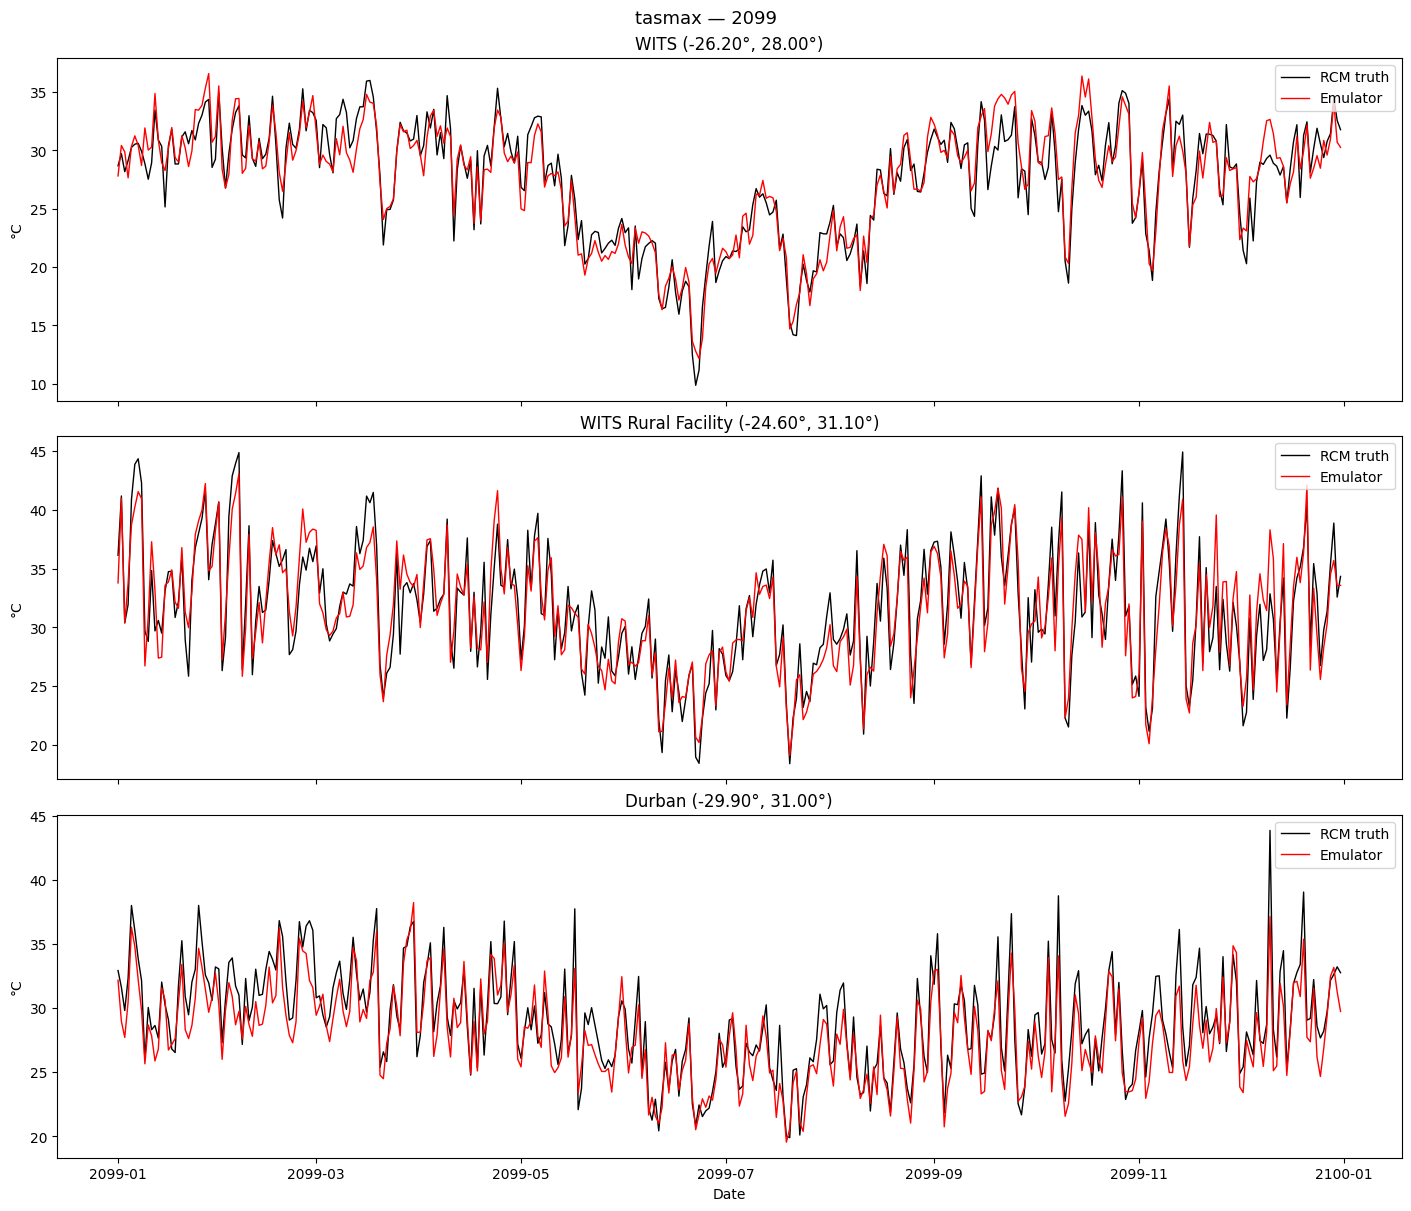

In [42]:
def plot_timeseries_for_year(
    ds_predictions,
    year: int,
    target: str,
    pinpoints: dict,  # e.g. {"WITS": (-26.19, 28.03)}
):

    tgt_lat = ds_predictions.lat.values
    tgt_lon = ds_predictions.lon.values

    units = {"pr": "mm/day", "tasmax": "°C"}
    ylabel = units.get(target, target)

    fig, axes = plt.subplots(
        len(pinpoints), 1,
        figsize=(14, 4 * len(pinpoints)),
        sharex=True,
        constrained_layout=True,
    )
    # Ensure axes is always iterable even for a single pinpoint
    if len(pinpoints) == 1:
        axes = [axes]

    for ax, (location, (lat, lon)) in zip(axes, pinpoints.items()):
        nearest_lat = float(tgt_lat[abs(tgt_lat - lat).argmin()])
        nearest_lon = float(tgt_lon[abs(tgt_lon - lon).argmin()])

        ts = ds_predictions.sel(lat=nearest_lat, lon=nearest_lon, time=str(year))

        ax.plot(
            ts.time, ts[f"target_{target}"],
            label="RCM truth", color="black", linewidth=1.0,
        )
        ax.plot(
            ts.time, ts[f"pred_{target}"],
            label="Emulator", color="red", linewidth=1.0,
        )
        ax.set_title(f"{location} ({nearest_lat:.2f}°, {nearest_lon:.2f}°)")
        ax.set_ylabel(ylabel)
        ax.legend(loc="upper right")

    axes[-1].set_xlabel("Date")
    fig.suptitle(f"{target} — {year}", fontsize=13)
    plt.show()


plot_timeseries_for_year(
    ds_predictions,
    year=2099,
    target="tasmax",
    pinpoints={
        "WITS": (-26.19, 28.03),
        "WITS Rural Facility": (-24.57, 31.10),
        "Durban": (-29.86, 31.02),
    },
)

### 7.3 Spatial maps

We plot predictions against RCM trucht for a selection of randomly chosen days. This gives a qualitative sense of whether the model is capturing the spatial structure of the target field.

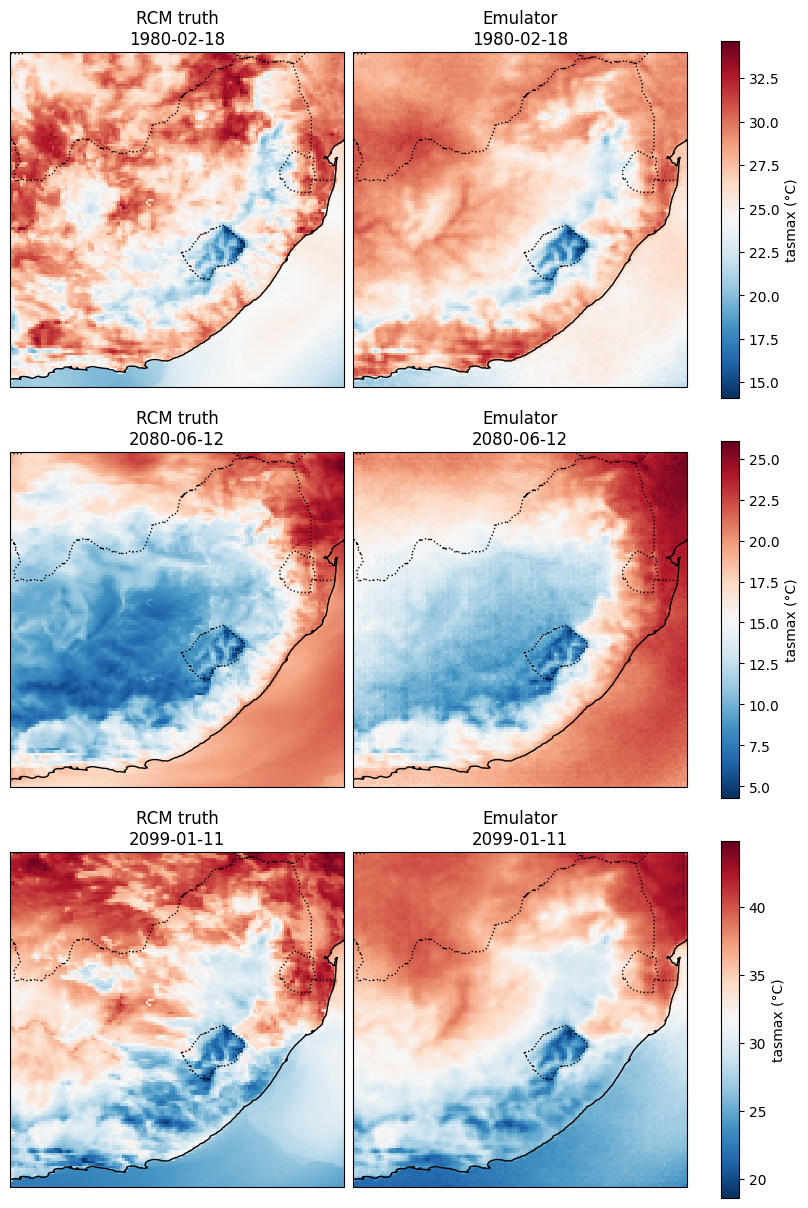

In [43]:
def plot_random_day_comparison(
    ds_predictions,
    target: str,
    n_days: int = 3,
    seed: int | None = None,
    cmap: str = "RdBu_r",
):

    units = {"pr": "mm/day", "tasmax": "°C"}
    unit_label = units.get(target, target)

    vmin = 0 if target == "pr" else None  # precipitation is non-negative; let tasmax float

    if seed is not None:
        np.random.seed(seed)
    all_times = ds_predictions.time.values
    selected_times = np.sort(
        all_times[np.random.choice(len(all_times), size=n_days, replace=False)]
    )

    fig, axes = plt.subplots(
        n_days, 2,
        figsize=(8, 4 * n_days),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )

    for i, t in enumerate(selected_times):
        date_str = np.datetime_as_string(t, unit="D")
        da_target = ds_predictions[f"target_{target}"].sel(time=t)
        da_pred   = ds_predictions[f"pred_{target}"].sel(time=t)

        vmax = float(np.nanmax([da_target.values, da_pred.values]))

        for ax, da, title in zip(
            [axes[i, 0], axes[i, 1]],
            [da_target, da_pred],
            ["RCM truth", "Emulator"],
        ):
            im = da.plot(
                ax=ax, cmap=cmap, transform=ccrs.PlateCarree(),
                vmin=vmin, vmax=vmax, add_colorbar=False,
            )
            ax.coastlines(resolution="10m")
            ax.add_feature(cfeature.BORDERS, linestyle=":")
            ax.set_title(f"{title}\n{date_str}")

        fig.colorbar(im, ax=axes[i, :], orientation="vertical", label=f"{target} ({unit_label})")

    plt.show()


# Usage
plot_random_day_comparison(ds_predictions, target="tasmax", n_days=3, seed=42, cmap="RdBu_r")

### 7.4 Long term averages

The following plots summarises model performance over the full test period at each grid cell. We plot:
- Long term mean
- 99th percentile
- Frequency of dry days (pr) /  frequency of hot days (tasmax)

for both the emulator and the RCM. We also show the bias between the two.

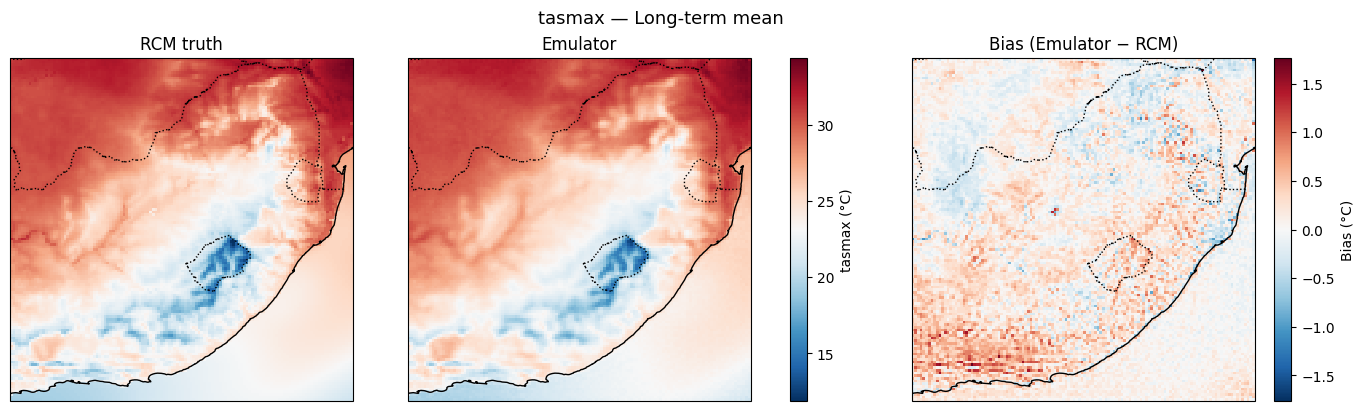

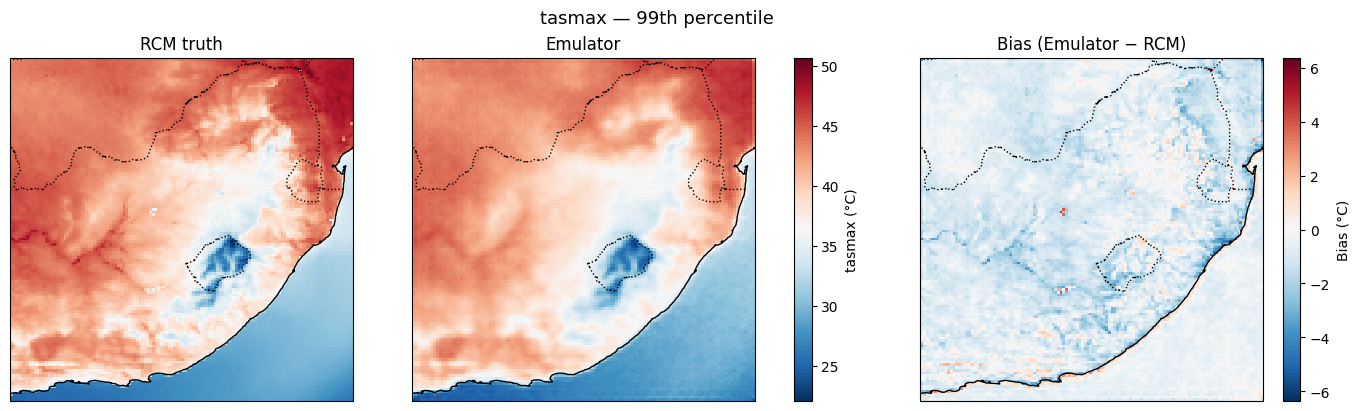

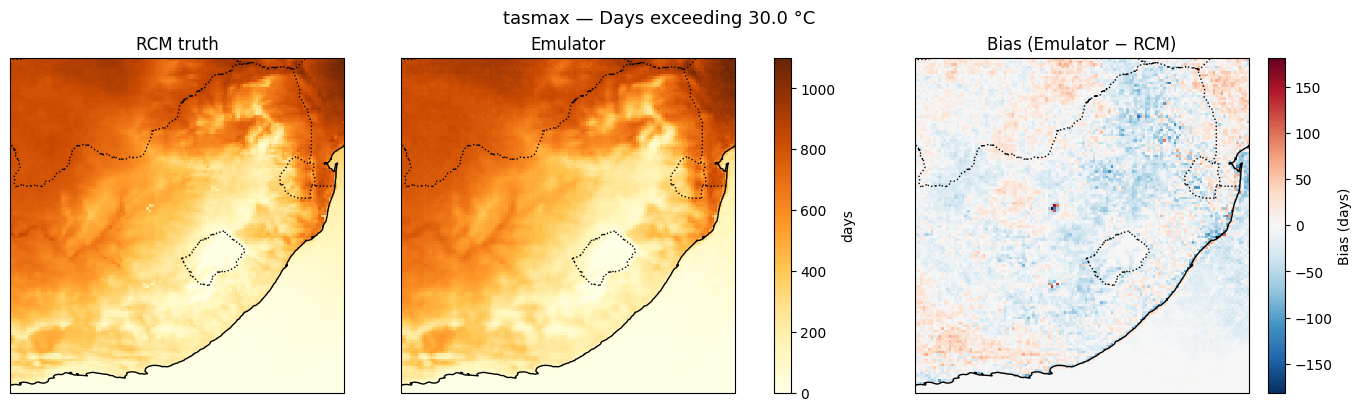

In [44]:
def plot_spatial_statistic(
    ds_predictions,
    target: str,
    statistic: str,
    cmap: str = "YlGnBu",
    frequency_threshold: float | None = None,
):
    """
    Three statistics are supported:
        - "mean":      long-term mean at each grid cell.
        - "p99":       99th percentile at each grid cell, a measure of extremes.
        - "frequency": for pr, percentage of dry days (< threshold).
                       for tasmax, number of days exceeding threshold.
    """

    units = {"pr": "mm/day", "tasmax": "°C"}
    unit_label = units.get(target, target)

    da_target = ds_predictions[f"target_{target}"]
    da_pred   = ds_predictions[f"pred_{target}"]

    if statistic == "mean":
        da_target_stat = da_target.mean(dim="time")
        da_pred_stat   = da_pred.mean(dim="time")
        stat_label     = "Long-term mean"
        cbar_label     = f"{target} ({unit_label})"

    elif statistic == "p99":
        da_target_stat = da_target.quantile(0.99, dim="time")
        da_pred_stat   = da_pred.quantile(0.99, dim="time")
        stat_label     = "99th percentile"
        cbar_label     = f"{target} ({unit_label})"

    elif statistic == "frequency":
        default_thresholds = {"pr": 1.0, "tasmax": 30.0}
        if frequency_threshold is None:
            if target not in default_thresholds:
                raise ValueError(
                    f"No default threshold for target '{target}'. "
                    f"Please provide frequency_threshold explicitly."
                )
            frequency_threshold = default_thresholds[target]

        n_days = len(ds_predictions.time)
        if target == "pr":
            da_target_stat = (da_target <= frequency_threshold).sum(dim="time") / n_days * 100
            da_pred_stat   = (da_pred   <= frequency_threshold).sum(dim="time") / n_days * 100
            stat_label     = f"Dry days (< {frequency_threshold} {unit_label})"
            cbar_label     = "% dry days"
        else:
            da_target_stat = (da_target > frequency_threshold).sum(dim="time")
            da_pred_stat   = (da_pred   > frequency_threshold).sum(dim="time")
            stat_label     = f"Days exceeding {frequency_threshold} {unit_label}"
            cbar_label     = "days"

    else:
        raise ValueError(
            f"Unsupported statistic '{statistic}'. Must be one of 'mean', 'p99', 'frequency'."
        )

    # Bias
    if target == "pr":
        diff       = (da_pred_stat - da_target_stat) / da_target_stat.where(da_target_stat > 0.1) * 100
        diff_label = "Relative bias (%)"
    else:
        diff       = da_pred_stat - da_target_stat
        diff_label = f"Bias ({unit_label})" if statistic != "frequency" else "Bias (days)"

    # Plot
    vmin = min(float(da_target_stat.min()), float(da_pred_stat.min()))
    vmax = max(float(da_target_stat.max()), float(da_pred_stat.max()))
    abs_max = float(abs(diff).max())

    fig, axes = plt.subplots(
        1, 3,
        figsize=(14, 4),
        subplot_kw={"projection": ccrs.PlateCarree()},
        constrained_layout=True,
    )

    for ax, da, title in zip(axes[:2],[da_target_stat, da_pred_stat],["RCM truth", "Emulator"]):
        im = da.plot(
            ax=ax, cmap=cmap, transform=ccrs.PlateCarree(),
            vmin=vmin, vmax=vmax, add_colorbar=False,
        )
        ax.coastlines(resolution="10m")
        ax.add_feature(cfeature.BORDERS, linestyle=":")
        ax.set_title(title)

    fig.colorbar(im, ax=axes[:2], orientation="vertical", label=cbar_label)

    im_diff = diff.plot(
        ax=axes[2], cmap="RdBu_r", transform=ccrs.PlateCarree(),
        vmin=-abs_max, vmax=abs_max, add_colorbar=False,
    )
    axes[2].coastlines(resolution="10m")
    axes[2].add_feature(cfeature.BORDERS, linestyle=":")
    axes[2].set_title("Bias (Emulator − RCM)")
    fig.colorbar(im_diff, ax=axes[2], orientation="vertical", label=diff_label)

    fig.suptitle(f"{target} — {stat_label}", fontsize=13)
    plt.show()


plot_spatial_statistic(ds_predictions, target="tasmax",     statistic="mean",      cmap="RdBu_r")
plot_spatial_statistic(ds_predictions, target="tasmax",     statistic="p99",       cmap="RdBu_r")
plot_spatial_statistic(ds_predictions, target="tasmax",     statistic="frequency", cmap="YlOrBr")

## 8. Next steps

This notebook has walked throug ha complete UNet downscaling pipeline as a baseline. There are many ways this could be extended and improved - some suggestions:

Predictors and targets:
- Re-run the model but for the other target variable
- Experimnt with different sets of predictors (which pressure level predictors prove to be the most skillful for predicting rainfall?)
- Add orography as a static field - you will find it in the same folder as the other predictors. You will need to think about how to add this as a predictor and note its resolution/domain

Loss functions:
- Try training precipitation with standard MAE or MSE and compaire agaisnt EmulASYM - how does the choice of loss function affect the prediction of extreme events

Evaluation:
- Compute quantitative metrics at particular locations and spatially over the target domain

## Useful References
Doury, Antoine, Samuel Somot, Sebastien Gadat, Aurélien Ribes, and Lola Corre. ‘Regional Climate Model Emulator Based on Deep Learning: Concept and First Evaluation of a Novel Hybrid Downscaling Approach’. Climate Dynamics 60, no. 5 (2023): 1751–79. https://doi.org/10.1007/s00382-022-06343-9.

Doury, Antoine, Samuel Somot, and Sebastien Gadat. ‘On the Suitability of a Convolutional Neural Network Based RCM-Emulator for Fine Spatio-Temporal Precipitation’. Climate Dynamics 62, no. 9 (2024): 8587–613. https://doi.org/10.1007/s00382-024-07350-8.

Rampal, N., González-Abad, J., Gibson, P., Engelbrecht, F., Steinkopf, J., & Hardy, C. (2025). CORDEX-ML-Bench: A benchmarking dataset for data-driven regional climate downscaling. Zenodo. https://doi.org/10.5281/zenodo.17957264